In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from snowflake.snowpark import Session

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
connection_parameters = {
    "account": "IJYGGJU-WI05238",
    "user": "Shank227",
    "password": "ShashankB2207$",
    "warehouse": "COMPUTE_WH",
    "database": "BANK_SEGMENTATION_DB",
    "schema": "PUBLIC",
    "role": "ACCOUNTADMIN"
}

In [4]:
session = Session.builder.configs(connection_parameters).create()
session.sql("SELECT CURRENT_VERSION()").show()

-----------------------
|"CURRENT_VERSION()"  |
-----------------------
|10.23.103            |
-----------------------



In [5]:
df = session.table("BANK_MARKETING_PROCESSED").to_pandas()

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
for col in df.columns:
    print(col)

AGE
DURATION
CAMPAIGN
PDAYS
PREVIOUS
EMPLOYMENT_RATE
CONSUMER_PRICE_INDEX
CONSUMER_CONFIDENCE_INDEX
EURIBOR3M
EMPLOYEES_COUNT
JOB_BLUE_COLLAR
JOB_ENTREPRENEUR
JOB_HOUSEMAID
JOB_MANAGEMENT
JOB_RETIRED
JOB_SELFEMPLOYED
JOB_SERVICES
JOB_STUDENT
JOB_TECHNICIAN
JOB_UNEMPLOYED
JOB_UNKNOWN
MARITAL_MARRIED
MARITAL_SINGLE
MARITAL_UNKNOWN
EDUCATION_BASIC6Y
EDUCATION_BASIC9Y
EDUCATION_HIGHSCHOOL
EDUCATION_ILLITERATE
EDUCATION_PROFESSIONALCOURSE
EDUCATION_UNIVERSITYDEGREE
EDUCATION_UNKNOWN
DEFAULT_UNKNOWN
DEFAULT_YES
HOUSING_UNKNOWN
HOUSING_YES
LOAN_UNKNOWN
LOAN_YES
CONTACT_TELEPHONE
MONTH_AUG
MONTH_DEC
MONTH_JUL
MONTH_JUN
MONTH_MAR
MONTH_MAY
MONTH_NOV
MONTH_OCT
MONTH_SEP
DAY_OF_WEEK_MON
DAY_OF_WEEK_THU
DAY_OF_WEEK_TUE
DAY_OF_WEEK_WED
POUTCOME_NONEXISTENT
POUTCOME_SUCCESS
AGE_GROUP
CONTACTED_BEFORE
HIGH_CAMPAIGN


In [8]:
df.info()
df.isnull().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 56 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   AGE                           41188 non-null  float64
 1   DURATION                      41188 non-null  float64
 2   CAMPAIGN                      41188 non-null  float64
 3   PDAYS                         41188 non-null  float64
 4   PREVIOUS                      41188 non-null  float64
 5   EMPLOYMENT_RATE               41188 non-null  float64
 6   CONSUMER_PRICE_INDEX          41188 non-null  float64
 7   CONSUMER_CONFIDENCE_INDEX     41188 non-null  float64
 8   EURIBOR3M                     41188 non-null  float64
 9   EMPLOYEES_COUNT               41188 non-null  float64
 10  JOB_BLUE_COLLAR               41188 non-null  float64
 11  JOB_ENTREPRENEUR              41188 non-null  float64
 12  JOB_HOUSEMAID                 41188 non-null  float64
 13  J

np.int64(0)

In [9]:
np.isinf(df).sum().sum()

np.int64(0)

In [10]:
#Starting ELBOW method for choosing correct amount clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df)

    wcss.append(kmeans.inertia_)

In [11]:
wcss

[2115419.9782568915,
 2017100.4121539432,
 1948256.399225663,
 1873459.608815565,
 1828119.295868731,
 1783623.5049221516,
 1723420.8269777086,
 1690183.475398575,
 1636328.2541165103]

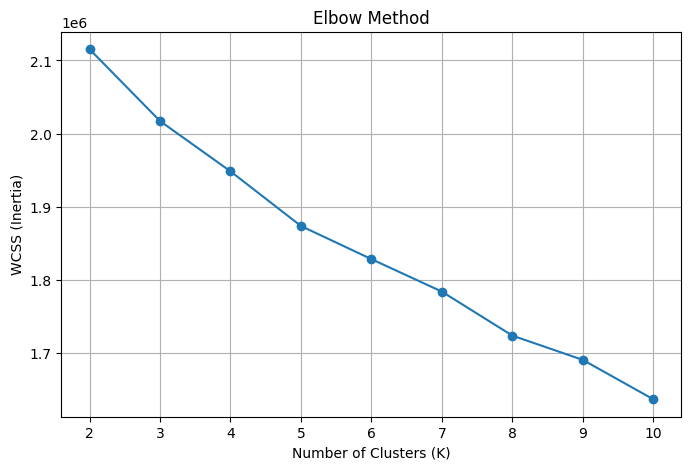

In [12]:
# Plot the Elbow Method graph

plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Test K values from 2 to 10
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(df)

    score = silhouette_score(df, cluster_labels)

    silhouette_scores.append(score)

In [14]:
silhouette_scores

[0.12370178331450181,
 0.0879329173991957,
 0.05976960371131889,
 0.0663979138516044,
 0.07901058555415781,
 0.08590813246879096,
 0.091137203238603,
 0.09343526663440853,
 0.10334269130777562]

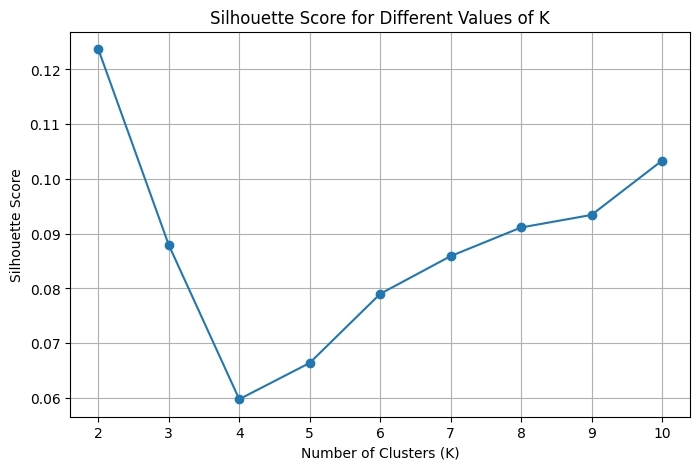

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Score for Different Values of K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(df)

df["Cluster"] = cluster_labels

In [17]:
df["Cluster"].value_counts()

Cluster
0    24071
2    11492
1     5625
Name: count, dtype: int64

In [18]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,AGE,DURATION,CAMPAIGN,PDAYS,PREVIOUS,EMPLOYMENT_RATE,CONSUMER_PRICE_INDEX,CONSUMER_CONFIDENCE_INDEX,EURIBOR3M,EMPLOYEES_COUNT,...,MONTH_SEP,DAY_OF_WEEK_MON,DAY_OF_WEEK_THU,DAY_OF_WEEK_TUE,DAY_OF_WEEK_WED,POUTCOME_NONEXISTENT,POUTCOME_SUCCESS,AGE_GROUP,CONTACTED_BEFORE,HIGH_CAMPAIGN
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.009587,-0.016327,0.132348,0.195414,-0.349494,0.774537,0.628412,0.307536,0.750467,0.678193,...,-0.118462,-0.010950,-0.017607,0.020083,0.019759,0.397706,-0.185700,0.019933,-0.397706,0.117655
1,0.041176,0.029330,-0.220376,-1.235467,2.209612,-1.188067,-0.765048,-0.250747,-1.228059,-1.239738,...,0.315245,-0.005596,0.001471,-0.003957,-0.016457,-2.514421,1.174053,0.008879,2.514421,-0.221247
2,-0.040235,0.019843,-0.169348,0.195414,-0.349494,-1.040811,-0.941794,-0.521427,-0.970819,-0.813719,...,0.093825,0.025675,0.036160,-0.040130,-0.033332,0.397706,-0.185700,-0.046097,-0.397706,-0.138145


In [19]:
cluster_profile[
    [
        "AGE",
        "CAMPAIGN",
        "PREVIOUS",
        "PDAYS",
        "EURIBOR3M",
        "AGE_GROUP",
        "CONTACTED_BEFORE",
        "HIGH_CAMPAIGN"
    ]
]

,AGE,CAMPAIGN,PREVIOUS,PDAYS,EURIBOR3M,AGE_GROUP,CONTACTED_BEFORE,HIGH_CAMPAIGN
Cluster,,,,,,,,
0,0.009587,0.132348,-0.349494,0.195414,0.750467,0.019933,-0.397706,0.117655
1,0.041176,-0.220376,2.209612,-1.235467,-1.228059,0.008879,2.514421,-0.221247
2,-0.040235,-0.169348,-0.349494,0.195414,-0.970819,-0.046097,-0.397706,-0.138145


In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(df.drop(columns=["Cluster"]))

df["PC1"] = components[:,0]
df["PC2"] = components[:,1]

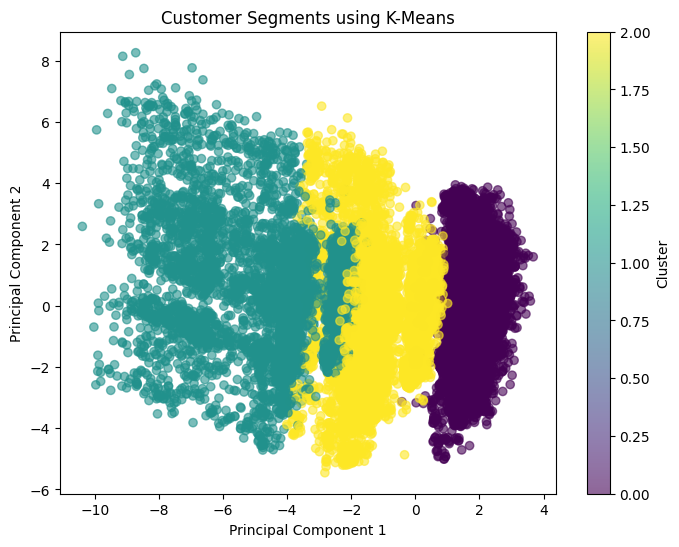

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["PC1"],
    df["PC2"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using K-Means")

plt.colorbar(label="Cluster")

plt.show()

In [22]:
session.write_pandas(
    df,
    "CUSTOMER_CLUSTERS",
    auto_create_table=True,
    overwrite=True
)

In [23]:
#job cluster (costumers)
job_columns = [col for col in df.columns if col.startswith("JOB_")]

df.groupby("Cluster")[job_columns].mean().T

Cluster,0,1,2
JOB_BLUE_COLLAR,0.049748,-0.110239,-0.050244
JOB_ENTREPRENEUR,-0.009654,-0.019104,0.029572
JOB_HOUSEMAID,0.035554,-0.036784,-0.056467
JOB_MANAGEMENT,-0.034592,0.018464,0.063419
JOB_RETIRED,-0.058191,0.136063,0.055287
JOB_SELFEMPLOYED,-0.004884,-0.018570,0.019320
JOB_SERVICES,0.012874,-0.014484,-0.019876
JOB_STUDENT,-0.097485,0.199113,0.106730
JOB_TECHNICIAN,0.041573,-0.044147,-0.065469
JOB_UNEMPLOYED,-0.019463,0.020099,0.030930


In [24]:
#Education Cluster (costumers)
education_columns = [col for col in df.columns if col.startswith("EDUCATION_")]

df.groupby("Cluster")[education_columns].mean().T

Cluster,0,1,2
EDUCATION_BASIC6Y,0.021659,-0.042665,-0.024483
EDUCATION_BASIC9Y,0.013171,-0.042481,-0.006796
EDUCATION_HIGHSCHOOL,-0.013872,0.047893,0.005613
EDUCATION_ILLITERATE,-0.003020,-0.003898,0.008234
EDUCATION_PROFESSIONALCOURSE,0.015318,-0.016018,-0.024245
EDUCATION_UNIVERSITYDEGREE,-0.046913,0.044121,0.076667
EDUCATION_UNKNOWN,0.009394,0.029769,-0.034248


In [25]:
marital_columns = [col for col in df.columns if col.startswith("MARITAL_")]

df.groupby("Cluster")[marital_columns].mean().T

Cluster,0,1,2
MARITAL_MARRIED,0.066007,-0.108161,-0.085315
MARITAL_SINGLE,-0.075481,0.114388,0.102111
MARITAL_UNKNOWN,-0.006372,0.028565,-0.000635
